# DRC Violation task experiment

### Baseline configuration
* max iterations: 15000, number of epochs: 150
* in/out channels: 9, 1
* threshold: 0.1 (this parameters is used to create the confusion matrix to calculate metrics)

In [27]:
# Imports
import pandas as pd
import os
import numpy as np
from aim.storage.context import Context
from aim import Repo
import matplotlib.pyplot as plt

# Basic utils
repo = Repo(path=os.getcwd())

def get_runs_by_experiment_name(experiment_name: str):
    query = ''
    query += ' run.active == False and'
    query += ' run.archived == False'
    query += f' and run.experiment == "{experiment_name}"'

    runs = repo.query_runs(query=query, report_mode=0)
    return runs.iter_runs()

def return_metrics_sorted(run, name, subset='global'):
    metric = run.get_metric(name, context=Context({'subset': subset}))
    ts = metric.timestamps.values_numpy()
    vals = metric.values.values_numpy()
    idx = np.argsort(ts)
    vals = vals[idx]
    return vals

def get_single_value_metric(run, name, subset='global'):
    metric = run.get_metric(name, context=Context({'subset': subset}))
    return metric.values.values_numpy()[0]

def get_hist_data_for_distribution(run, name):
    sequences_info = run.collect_sequence_info(sequence_types=['distributions'])
    if 'distributions' in sequences_info:
        for dist_info in sequences_info['distributions']:
            if dist_info['name'] == name:
                last = dist_info['values']['last']
                return last.to_np_histogram()

def plot_histograms(histograms_data, title=None, unit='GB'):
    items = [(k, v) for k, v in histograms_data.items() if v is not None]
    if not items:
        return

    fig, axes = plt.subplots(1, len(items), figsize=(5 * len(items), 4), constrained_layout=True)
    if len(items) == 1:
        axes = [axes]

    for ax, (name, (counts, _)) in zip(axes, items):


        ax.hist(counts, bins=30, edgecolor='black', alpha=0.7)
        ax.set_title(name)
        ax.set_xlabel(unit)
        ax.set_ylabel(name)

        ax.text(
            0.98,
            0.98,
            f"mean={np.mean(counts):.4f} {unit}\nstd={np.std(counts):.4f} {unit}",
            transform=ax.transAxes,
            ha='right',
            va='top',
            fontsize=9,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.7'),
        )

    if title:
        fig.suptitle(title)

    plt.show()

## Train results
Print the configuration we used

In [28]:
train_runs = get_runs_by_experiment_name('drc_centralized_train')

train_conf_table_content = []
id = 1
for run in train_runs:
    run = run.run 
    hparams = run.get('hparams')

    conf_dict = {
        'tag': run.tags[0],
        'batch_size': hparams['batch_size'],
        'eval_metrics': hparams['eval_metric'],
        'loss_type': hparams['loss_type'],
        'lr': hparams['lr'],
        'threshold': hparams['threshold'],
        'weight_decay': hparams['weight_decay']
    }

    id += 1
    train_conf_table_content.append(conf_dict)

train_conf_df = pd.DataFrame(train_conf_table_content)
display(train_conf_df)

,tag,batch_size,eval_metrics,loss_type,lr,threshold,weight_decay
0,high_weight_decay,8,"[NRMS, SSIM]",MSELoss,0.00005,0.1,0.0010
1,high_lr_bs,16,"[NRMS, SSIM]",MSELoss,0.00100,0.1,0.0001
2,L1_loss,8,"[NRMS, SSIM]",L1Loss,0.00020,0.1,0.0001
3,Baseline,8,"[NRMS, SSIM]",MSELoss,0.00020,0.1,0.0001


## Train results graphs (epoch loss and pixel loss per iteration)

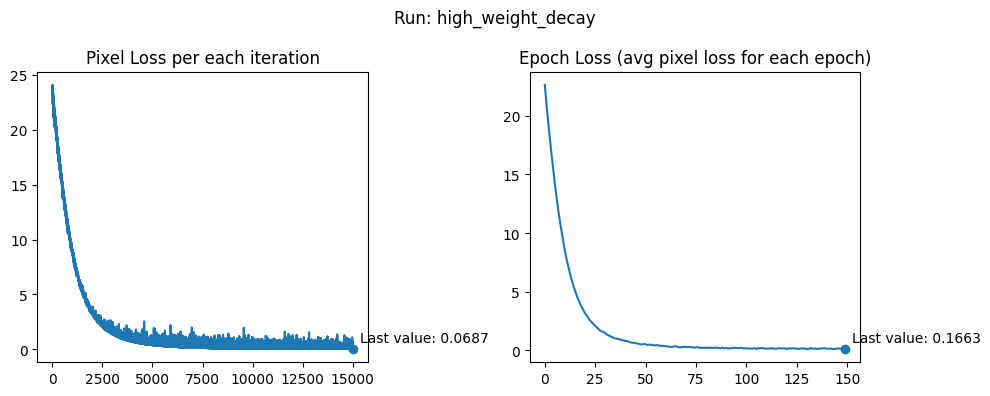

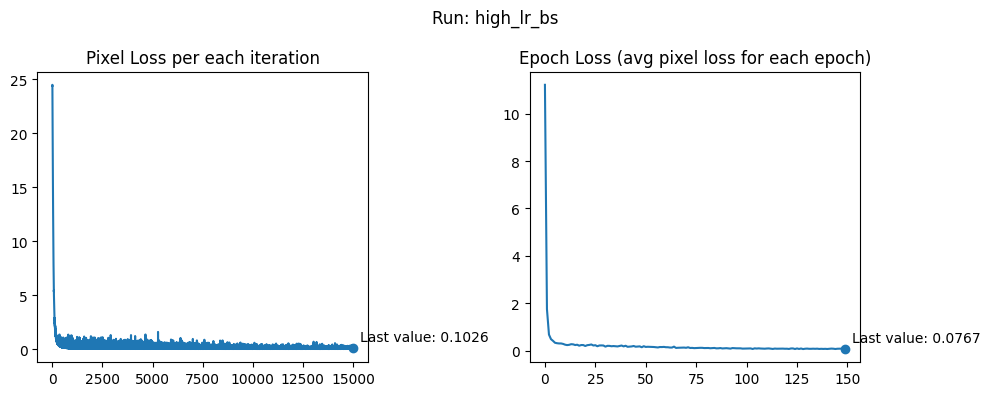

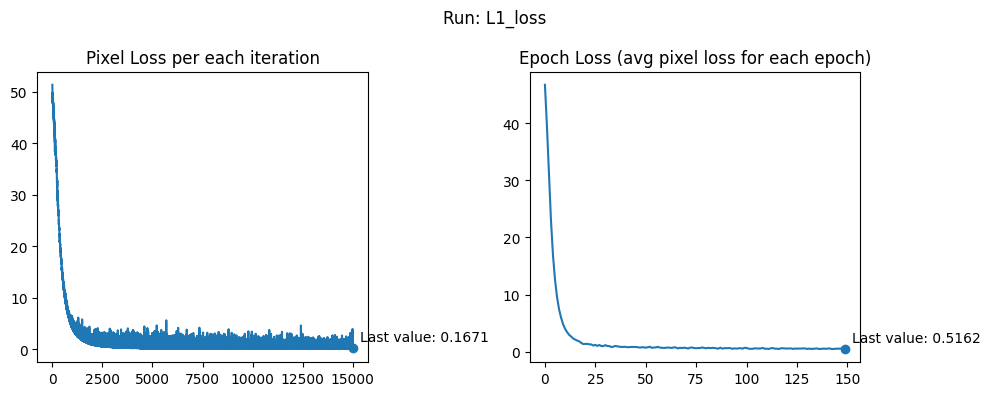

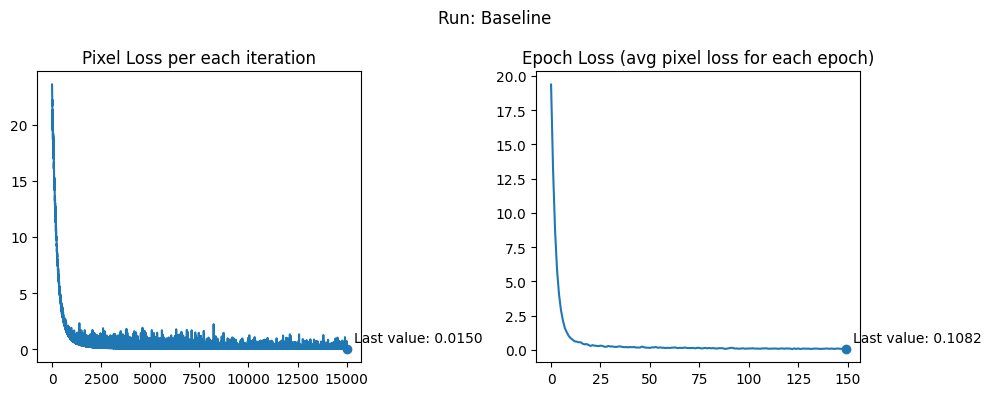

,tag,pixel_loss,epoch_loss
0,high_weight_decay,0.068691,0.166294
1,high_lr_bs,0.102639,0.076746
2,L1_loss,0.167109,0.516245
3,Baseline,0.015046,0.108233


In [29]:
train_runs = get_runs_by_experiment_name('drc_centralized_train')
loss_table_content = []

for run in train_runs:
    pixel_loss_vals = return_metrics_sorted(run.run, 'Pixel Loss')
    epoch_loss_vals = return_metrics_sorted(run.run, 'Epoch Loss')

    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    plt.suptitle(f"Run: {run.run.tags[0]}")

    # --- First plot ---
    axes[0].plot(pixel_loss_vals)
    axes[0].set_title("Pixel Loss per each iteration")

    best_val_0 = pixel_loss_vals[-1]
    best_idx_0 = len(pixel_loss_vals) - 1

    axes[0].scatter(best_idx_0, best_val_0)
    axes[0].annotate(
        f"Last value: {best_val_0:.4f}",
        (best_idx_0, best_val_0),
        textcoords="offset points",
        xytext=(5, 5)
    )

    # --- Second plot ---
    axes[1].plot(epoch_loss_vals)
    axes[1].set_title("Epoch Loss (avg pixel loss for each epoch)")

    best_idx_1 = len(epoch_loss_vals) - 1
    best_val_1 = epoch_loss_vals[-1]

    axes[1].scatter(best_idx_1, best_val_1)
    axes[1].annotate(
        f"Last value: {best_val_1:.4f}",
        (best_idx_1, best_val_1),
        textcoords="offset points",
        xytext=(5, 5)
    )

    plt.tight_layout()
    plt.show()

    loss_table_content.append({
        'tag': run.run.tags[0],
        'pixel_loss': pixel_loss_vals[-1],
        'epoch_loss': epoch_loss_vals[-1]
    })

display(pd.DataFrame(loss_table_content))
    

### Train validation results per epoch

,tag,last validation NRMS,last validation SSIM
0,high_weight_decay,0.441312,0.354832
1,high_lr_bs,0.116943,0.917171
2,L1_loss,0.048185,0.950444
3,Baseline,0.170351,0.829602


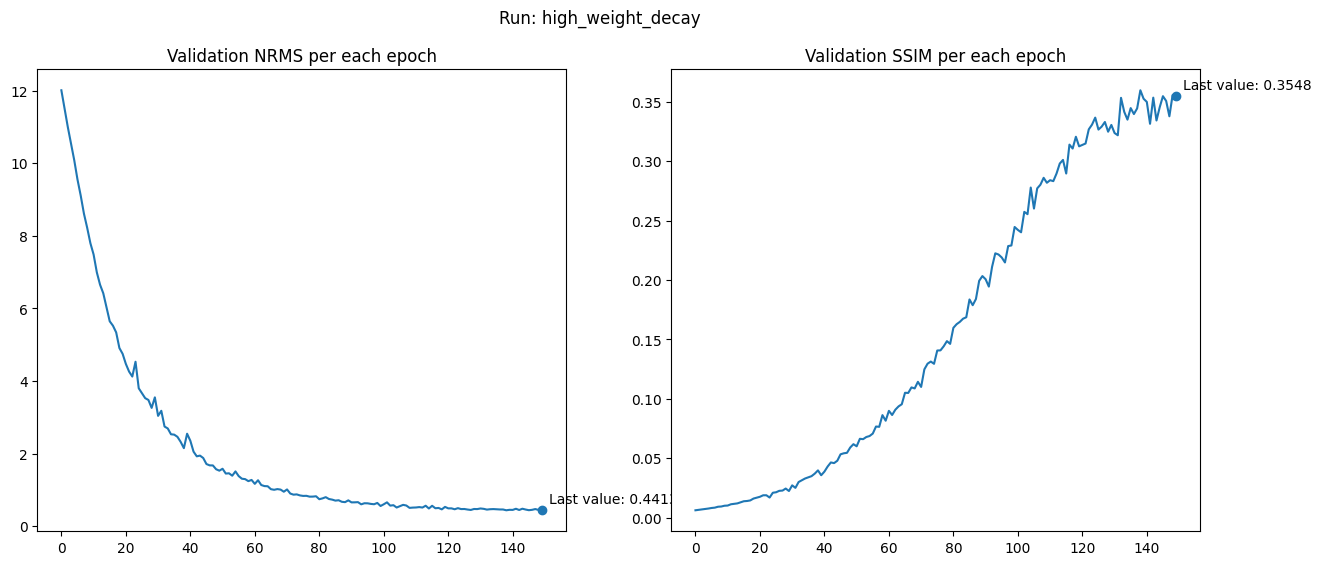

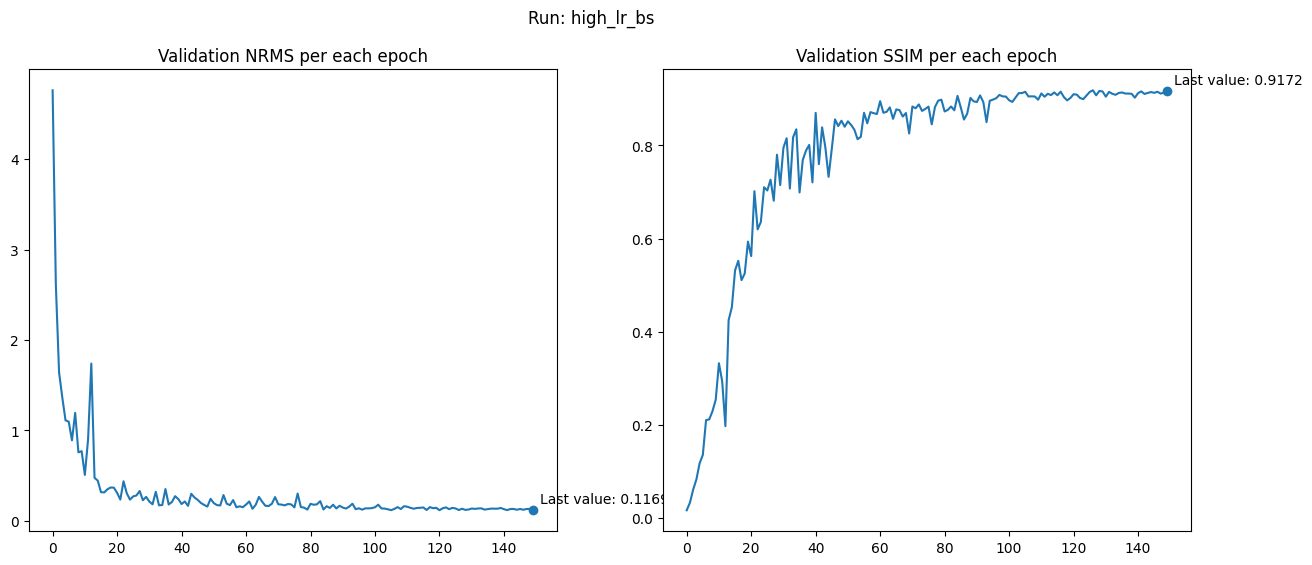

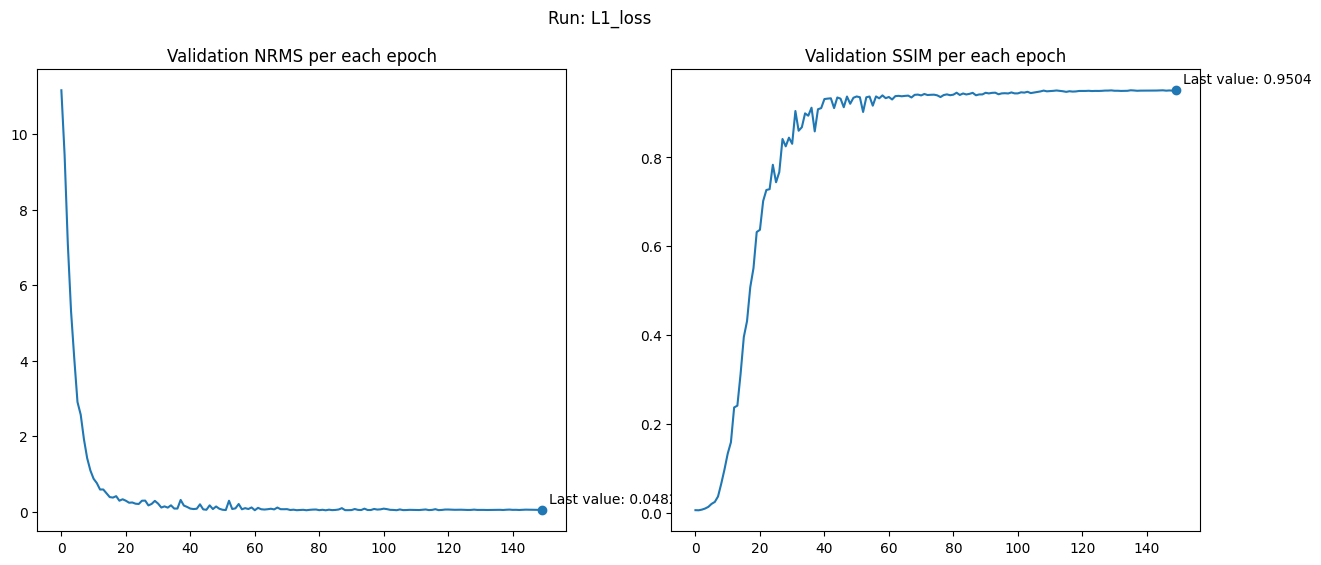

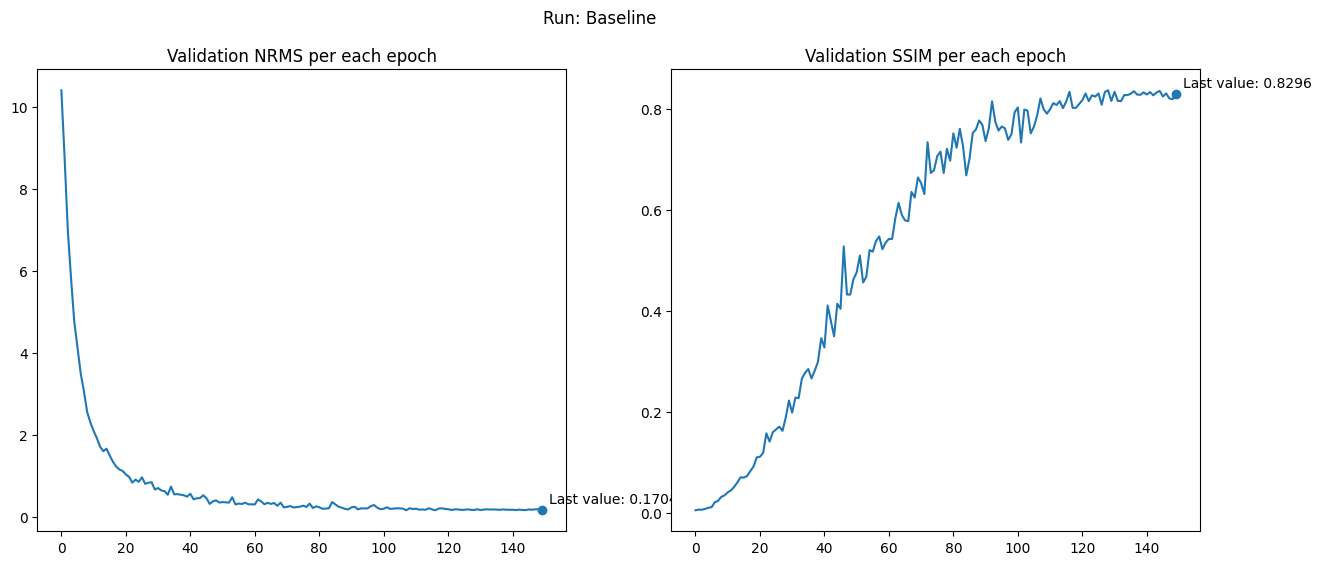

In [30]:
train_runs = get_runs_by_experiment_name('drc_centralized_train')
validate_table_content = []

for run in train_runs:
    run = run.run 
    hparams = run.get('hparams')

    eval_metric = hparams['eval_metric']
    validate_dict = {
        'tag': run.tags[0]
    }

    fig, axes = plt.subplots(len(eval_metric) // 2 + len(eval_metric) % 2, 2, figsize=(15, 6 * (len(eval_metric) // 2 + len(eval_metric) % 2)))
    axes = axes.flatten()
    plt.suptitle(f"Run: {run.tags[0]}")
    for i, metric in enumerate(eval_metric):
        metric_values = return_metrics_sorted(run, f"Val {metric}", subset='val')
        axes[i].plot(metric_values)
        axes[i].set_title(f"Validation {metric} per each epoch")

        best_val = metric_values[-1]
        best_idx = len(metric_values) - 1

        axes[i].scatter(best_idx, best_val)
        axes[i].annotate(
            f"Last value: {best_val:.4f}",
            (best_idx, best_val),
            textcoords="offset points",
            xytext=(5, 5)
        )
        validate_dict[f"last validation {metric}"] = best_val
        

    validate_table_content.append(validate_dict)

display(pd.DataFrame(validate_table_content))

### Test results distribution

AUC: 0.9126


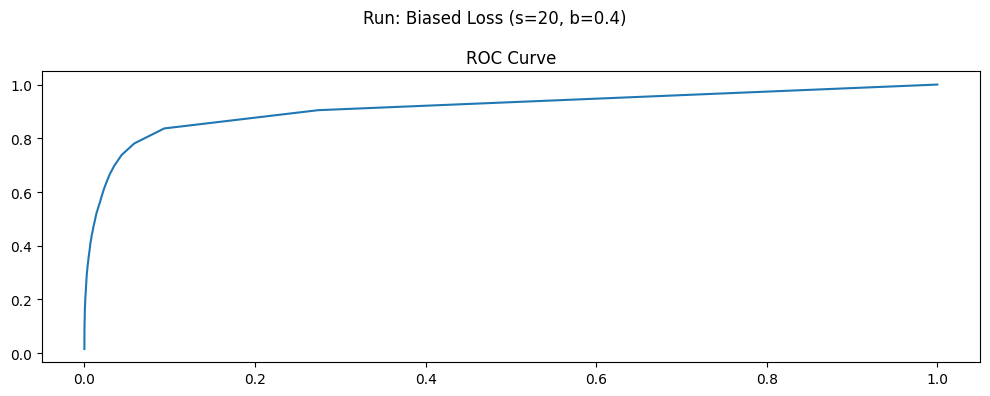

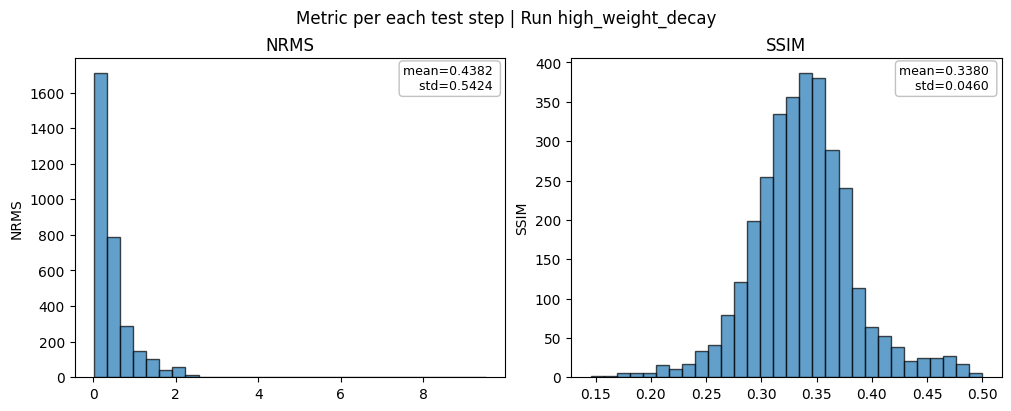

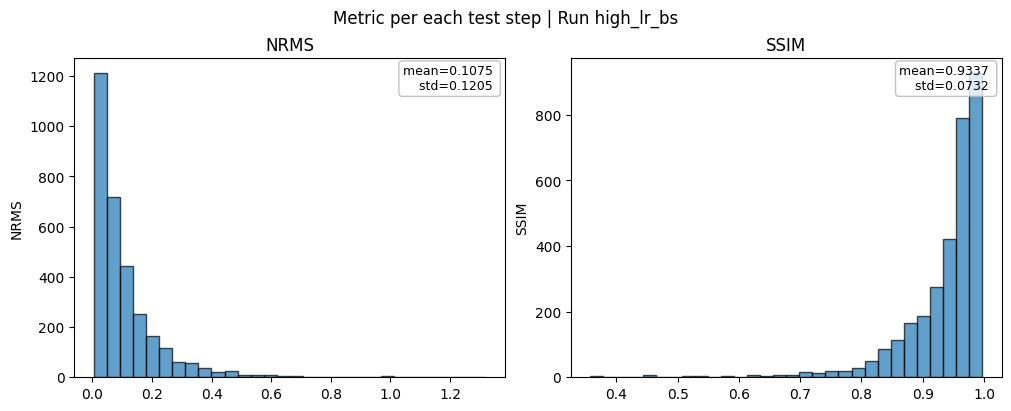

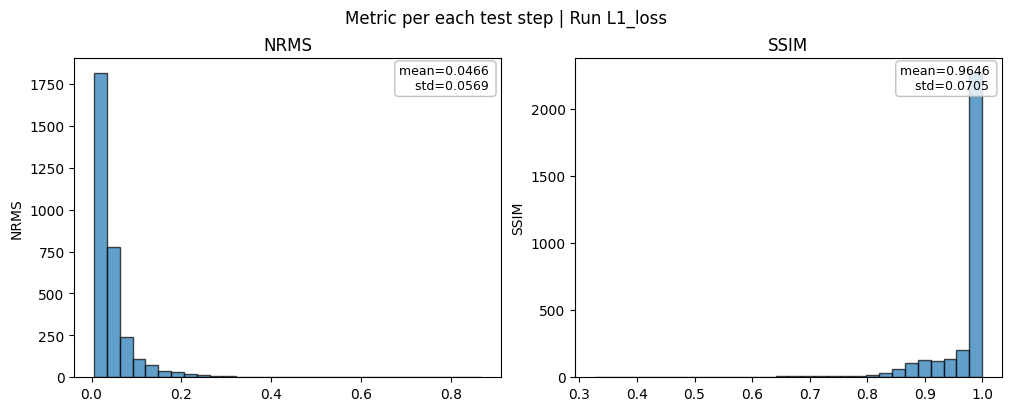

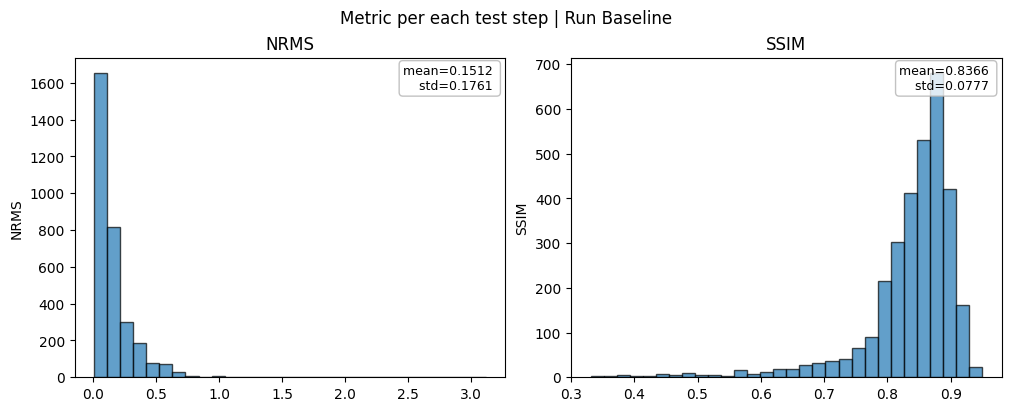

,tag
0,"Biased Loss (s=20, b=0.4)"
1,high_weight_decay
2,high_lr_bs
3,L1_loss
4,Baseline


In [33]:
test_runs = get_runs_by_experiment_name('drc_centralized_test')
test_res_content = []
for run in test_runs:
    run = run.run 
    # SSIM_value = get_single_value_metric(run, f"Test SSIM", subset='test')
    # NRMS_value = get_single_value_metric(run, f"Test NRMS", subset='test')
    # AUC_of_ROC_value = get_single_value_metric(run, f"Test AUC of ROC", subset='test')
    test_dict = {
        'tag': run.tags[0],
        #'test SSIM': SSIM_value,
        #'test NRMS': NRMS_value,
        # 'test AUC of ROC': AUC_of_ROC_value
    }
    test_res_content.append(test_dict)
    histogram_data = {
        'NRMS': get_hist_data_for_distribution(run, 'NRMS'),
        'SSIM': get_hist_data_for_distribution(run, 'SSIM'),
    }   

    metric = run.get_metric("ROC_TPR", context=Context({'type': 'curve'}))
    if metric is not None:
        ts = metric.timestamps.values_numpy()
        vals = metric.values.values_numpy()
        idx = np.argsort(ts)
        vals_tpr = vals[idx]

        metric = run.get_metric("ROC_FPR", context=Context({'type': 'curve'}))
        ts = metric.timestamps.values_numpy()
        vals = metric.values.values_numpy()
        idx = np.argsort(ts)
        vals_fpr = vals[idx]

        fig, axes = plt.subplots(1, 1, figsize=(10, 4))
        plt.suptitle(f"Run: {run.tags[0]}")
        axes.plot(vals_fpr, vals_tpr)
        axes.set_title("ROC Curve")
        area = 0
        for i in range(1, len(vals_fpr)):
            area += (vals_fpr[i] - vals_fpr[i-1]) * (vals_tpr[i] + vals_tpr[i-1]) / 2
        print(f"AUC: {area:.4f}")

        plt.tight_layout()
        plt.show()

    plot_histograms(histogram_data, title=f"Metric per each test step | Run {run.tags[0]}", unit='')

display(pd.DataFrame(test_res_content))
    